# 09 — Train Baseline CNN

## Goal

Train a simple 1D CNN baseline on the fixed subject-level training split and
evaluate development performance on the validation subjects.

### Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import balanced_accuracy_score

### Paths and Settings

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device:", device)

Device: mps


### Load EEG arrays

In [3]:
X = np.load(
    DATA_DIR / "X_motor_imagery.npy",
    mmap_mode="r"
)

y = np.load(
    DATA_DIR / "y_motor_imagery.npy",
    mmap_mode="r"
)

subjects = np.load(
    DATA_DIR / "subjects.npy",
    mmap_mode="r"
)

runs = np.load(
    DATA_DIR / "runs.npy",
    mmap_mode="r"
)

print("X:", X.shape)
print("y:", y.shape)
print("Subjects:", len(np.unique(subjects)))

X: (4898, 64, 481)
y: (4898,)
Subjects: 109


### Load predetermined split

In [4]:
split_table = pd.read_csv(
    RESULTS_DIR / "week9_subject_split.csv"
)

train_subjects = split_table.loc[
    split_table["split"] == "train",
    "subject"
].to_numpy()

val_subjects = split_table.loc[
    split_table["split"] == "validation",
    "subject"
].to_numpy()

test_subjects = split_table.loc[
    split_table["split"] == "test",
    "subject"
].to_numpy()

train_indices = np.flatnonzero(
    np.isin(subjects, train_subjects)
)

val_indices = np.flatnonzero(
    np.isin(subjects, val_subjects)
)

print("Training subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))

print("Training trials:", len(train_indices))
print("Validation trials:", len(val_indices))

Training subjects: 76
Validation subjects: 16
Training trials: 3423
Validation trials: 718


### Build dataset loader

In [5]:
class EEGDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = X
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        trial_index = self.indices[index]

        x = torch.tensor(
            self.X[trial_index],
            dtype=torch.float32
        ) * 1e6

        y = torch.tensor(
            self.y[trial_index],
            dtype=torch.long
        )

        return x, y

### Create datasets

In [6]:
train_dataset = EEGDataset(
    X,
    y,
    train_indices
)

val_dataset = EEGDataset(
    X,
    y,
    val_indices
)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))

Training examples: 3423
Validation examples: 718


### Make dataloaders

In [7]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=train_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

### Define baseline CNN

In [8]:
class SimpleEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=64,
                out_channels=16,
                kernel_size=15,
                padding=7
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=15,
                padding=7
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.classifier = nn.Linear(
            32 * 120,
            2
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)

        return x

### Intialize model

In [9]:
model = SimpleEEGCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

SimpleEEGCNN(
  (features): Sequential(
    (0): Conv1d(64, 16, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(15,), stride=(1,), padding=(7,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=3840, out_features=2, bias=True)
)


### Train one epoch function

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        all_targets.extend(
            y_batch.cpu().numpy()
        )
        all_predictions.extend(
            predictions.cpu().numpy()
        )

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Validation function

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=1)

            all_targets.extend(
                y_batch.cpu().numpy()
            )
            all_predictions.extend(
                predictions.cpu().numpy()
            )

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Train one epoch

In [12]:
train_loss, train_ba = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

val_loss, val_ba = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print(f"Train loss: {train_loss:.4f}")
print(f"Train BA:   {train_ba:.3f}")
print(f"Val loss:   {val_loss:.4f}")
print(f"Val BA:     {val_ba:.3f}")

Train loss: 0.9557
Train BA:   0.493
Val loss:   0.8749
Val BA:     0.480


### Preserve epoch 1

In [13]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

history = [{
    "epoch": 1,
    "train_loss": train_loss,
    "train_ba": train_ba,
    "val_loss": val_loss,
    "val_ba": val_ba
}]

best_val_ba = val_ba
best_epoch = 1

torch.save(
    model.state_dict(),
    MODELS_DIR / "baseline_cnn_best.pt"
)

### Train epochs 2-30

In [14]:
for epoch in range(2, 31):

    train_loss, train_ba = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_ba = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_ba": train_ba,
        "val_loss": val_loss,
        "val_ba": val_ba
    })

    if val_ba > best_val_ba:
        best_val_ba = val_ba
        best_epoch = epoch
        

        torch.save(
            model.state_dict(),
            MODELS_DIR / "baseline_cnn_best.pt"
        )

    print(
        f"Epoch {epoch:2d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train BA: {train_ba:.3f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val BA: {val_ba:.3f}"
    )

Epoch  2 | Train loss: 0.7202 | Train BA: 0.578 | Val loss: 0.8217 | Val BA: 0.487
Epoch  3 | Train loss: 0.6238 | Train BA: 0.639 | Val loss: 0.8335 | Val BA: 0.488
Epoch  4 | Train loss: 0.5591 | Train BA: 0.692 | Val loss: 0.8386 | Val BA: 0.494
Epoch  5 | Train loss: 0.5069 | Train BA: 0.743 | Val loss: 0.8440 | Val BA: 0.494
Epoch  6 | Train loss: 0.4607 | Train BA: 0.785 | Val loss: 0.8710 | Val BA: 0.504
Epoch  7 | Train loss: 0.4184 | Train BA: 0.816 | Val loss: 0.8960 | Val BA: 0.512
Epoch  8 | Train loss: 0.3870 | Train BA: 0.835 | Val loss: 0.9309 | Val BA: 0.509
Epoch  9 | Train loss: 0.3573 | Train BA: 0.854 | Val loss: 0.9728 | Val BA: 0.515
Epoch 10 | Train loss: 0.3210 | Train BA: 0.881 | Val loss: 1.0205 | Val BA: 0.511
Epoch 11 | Train loss: 0.2981 | Train BA: 0.891 | Val loss: 1.0439 | Val BA: 0.518
Epoch 12 | Train loss: 0.2773 | Train BA: 0.903 | Val loss: 1.0529 | Val BA: 0.512
Epoch 13 | Train loss: 0.2495 | Train BA: 0.918 | Val loss: 1.0887 | Val BA: 0.511
Epoc

### Preserve epochs

In [15]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    RESULTS_DIR / "baseline_cnn_training_history.csv",
    index=False
)

print("Best epoch:", best_epoch)
print("Best validation BA:", best_val_ba)

Best epoch: 16
Best validation BA: 0.5280753229011426


### Plot balanced accuracy

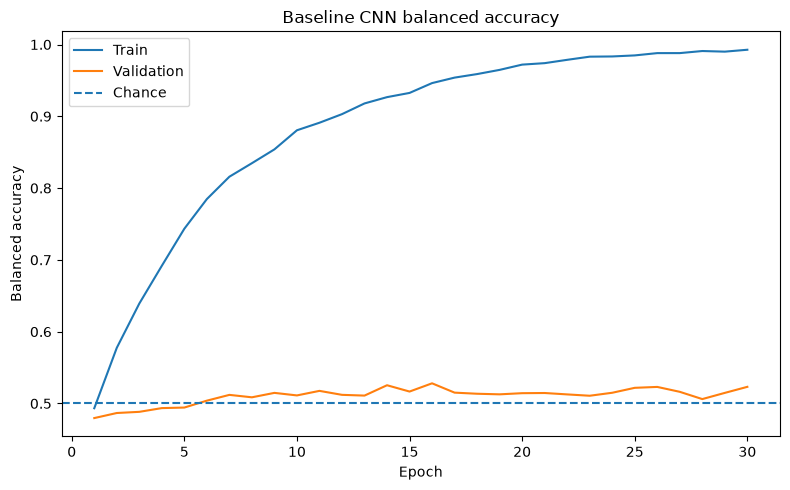

In [16]:
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_ba"],
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_ba"],
    label="Validation"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Chance"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced accuracy")
plt.title("Baseline CNN balanced accuracy")
plt.legend()

plt.savefig(
    FIGURES_DIR / "baseline_cnn_balanced_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Plot loss

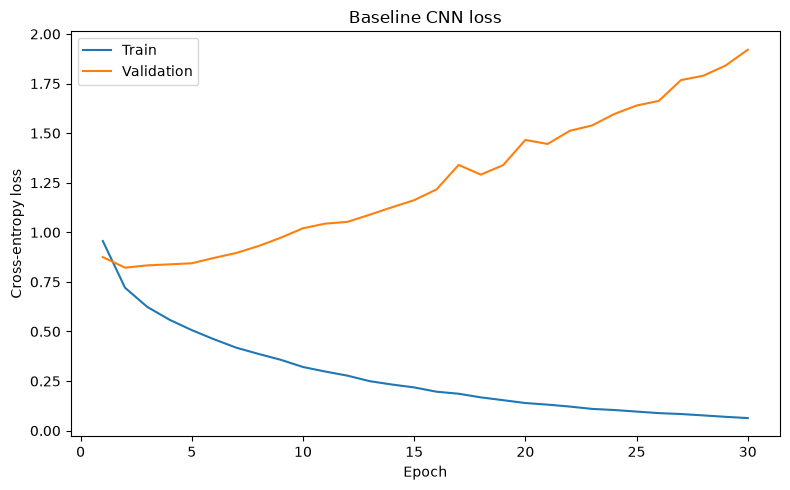

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Baseline CNN loss")
plt.legend()

plt.savefig(
    FIGURES_DIR / "baseline_cnn_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## Conclusion

The simple 1D CNN successfully learned the training data, reaching a
balanced accuracy of 0.993 by epoch 30.

However, performance did not transfer well to unseen validation subjects.
Validation balanced accuracy remained close to chance throughout training,
with a maximum of 0.528 at epoch 16.

Training loss continuously decreased while validation loss increased,
showing substantial overfitting. The model became increasingly confident
on the training data without learning a representation that generalized
well across subjects.

The held-out test subjects were not evaluated.

This establishes the simple CNN as a deep-learning baseline rather than a
successful cross-subject motor-imagery classifier.